# EmotionData

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# CELLULE 2 : Mes chemins de dossiers

In [6]:
DATA_PATH = r"C:\Users\DELL\emotion-detection\emotion-detection-fer\versions\1"

In [7]:
train_folder = DATA_PATH + "\\train"
test_folder = DATA_PATH + "\\test"

print("Dossier train:", train_folder)
print("Dossier test:", test_folder)

Dossier train: C:\Users\DELL\emotion-detection\emotion-detection-fer\versions\1\train
Dossier test: C:\Users\DELL\emotion-detection\emotion-detection-fer\versions\1\test


# CELLULE 3 : Charger mes images


In [10]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_folder,
    image_size=(48, 48),      # Taille des images
    batch_size=32,            # 32 images à la fois
    color_mode='grayscale',   # Noir et blanc
    validation_split=0.2,     # 20% pour la validation
    subset="training",
    seed=123
)

# Charger les images de validation
val_data = tf.keras.utils.image_dataset_from_directory(
    train_folder,
    image_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


# CELLULE 4 : Voir mes emotions


In [11]:
emotions = train_data.class_names
print(" Émotions:", emotions)
print(" Nombre d'émotions:", len(emotions))

 Émotions: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
 Nombre d'émotions: 7


# CELLULE 5 : Voir des exemples d'images


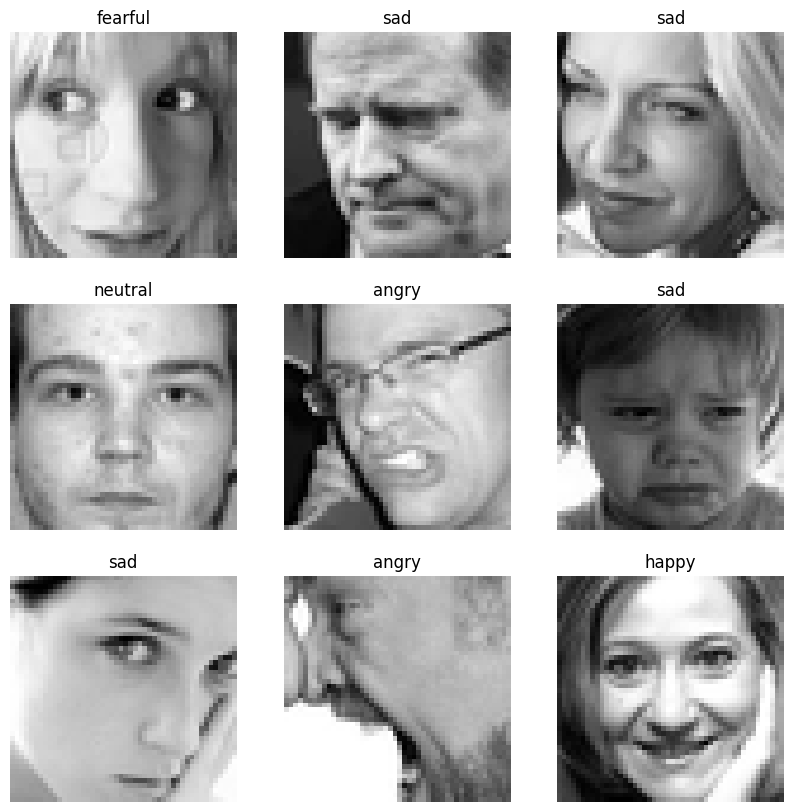

In [12]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(emotions[labels[i]])
        plt.axis("off")

plt.show()

# CELLULE 6 : Preparer mes donnees

In [ ]:
train_data = train_data.map(lambda x, y: (x/255.0, y))
val_data = val_data.map(lambda x, y: (x/255.0, y))

# CELLULE 7 : Creer mon modele CNN (simple)


In [16]:
model = tf.keras.Sequential([
    # Couche 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Couche 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Couche 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Aplatir
    tf.keras.layers.Flatten(),
    
    # Couches denses
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(emotions), activation='softmax')
])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# CELLULE 8 : Configurer le modèle


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CELLULE 9 : ENTRAINER ! 


In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20  # 15 tours d'entraînement
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.6771 - loss: 0.8358 - val_accuracy: 0.5433 - val_loss: 1.3769
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.6900 - loss: 0.8055 - val_accuracy: 0.5414 - val_loss: 1.4039
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.7003 - loss: 0.7773 - val_accuracy: 0.5344 - val_loss: 1.4293
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7049 - loss: 0.7598 - val_accuracy: 0.5471 - val_loss: 1.4581
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.7184 - loss: 0.7324 - val_accuracy: 0.5415 - val_loss: 1.5347
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7259 - loss: 0.7040 - val_accuracy: 0.5391 - val_loss: 1.6057
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7321 - loss: 0.6817 - val_accuracy: 0.5320 - val_loss: 1.6263
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.7412 - loss: 0.6580 - 

# CELLULE 10 : Sauvegarder le modele

In [21]:
os.makedirs('models', exist_ok=True)

# Sauvegarder
model.save('models/emotion_model.h5')
print("Modèle sauvegardé dans models/emotion_model.h5")

# Sauvegarder aussi les noms d'émotions
import json
with open('models/emotions.json', 'w') as f:
    json.dump(emotions, f)
print("Émotions sauvegardées dans models/emotions.json")

Modèle sauvegardé dans models/emotion_model.h5
Émotions sauvegardées dans models/emotions.json


# CELLULE 11 : Voir les résultats


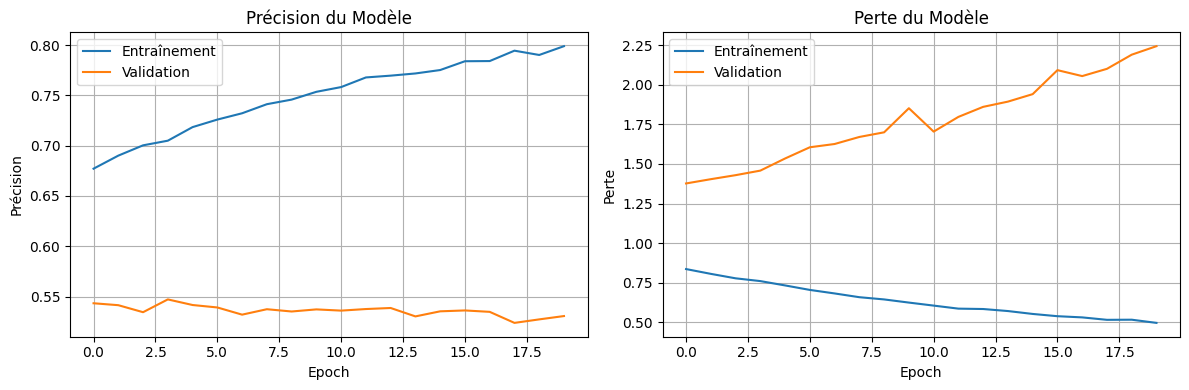

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entraînement')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Précision du Modèle')
plt.xlabel('Epoch')
plt.ylabel('Précision')
plt.legend()
plt.grid(True)

# Graphique de perte
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entraînement')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Perte du Modèle')
plt.xlabel('Epoch')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()  

# CELLULE 12 : Tester mon modèle


In [ ]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    image_size=(48, 48),
    batch_size=32,
    color_mode='grayscale'
)

# Normaliser
test_data = test_data.map(lambda x, y: (x/255.0, y))

# Évaluer
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nPrecision sur les images de test: {test_accuracy*100:.2f}%")

Found 7178 files belonging to 7 classes.
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.5369 - loss: 2.1407

Précision sur les images de test: 53.69%


# CELLULE 13 : Voir quelques prédictions


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


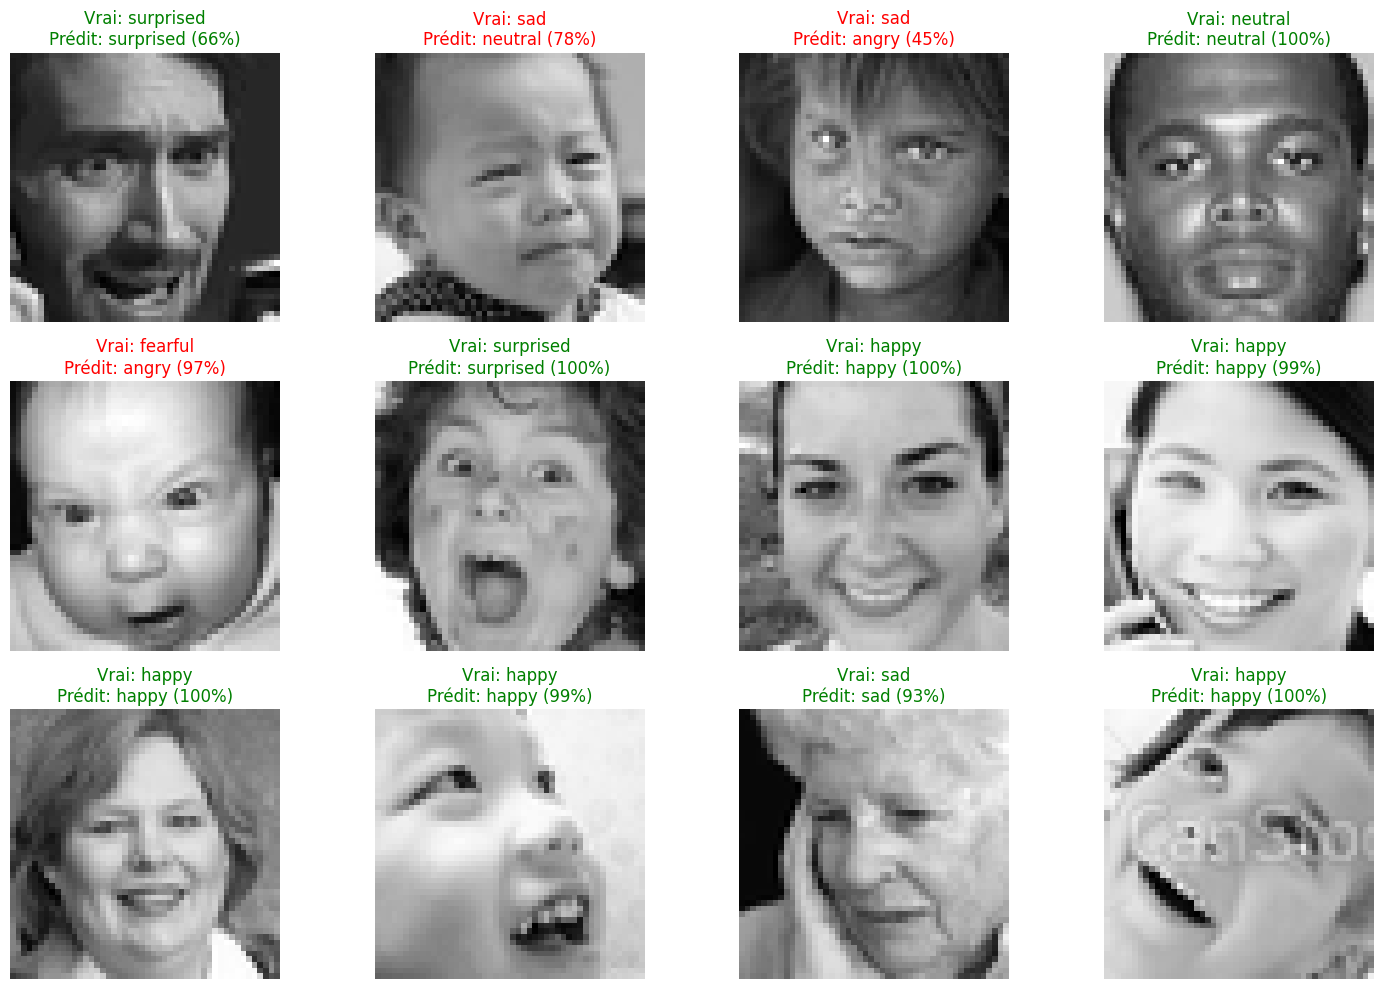

In [26]:
plt.figure(figsize=(15, 10))

for images, labels in test_data.take(1):
    predictions = model.predict(images)
    
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        
        # Vraie émotion
        true_emotion = emotions[labels[i]]
        
        # Émotion prédite
        pred_emotion = emotions[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        
        # Couleur : vert si correct, rouge si faux
        color = 'green' if true_emotion == pred_emotion else 'red'
        plt.title(f"Vrai: {true_emotion}\nPrédit: {pred_emotion} ({confidence:.0f}%)", 
                 color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

